<a href="https://colab.research.google.com/github/nathaliaacouto/ADES_Wine_Quality/blob/main/%5BADES%5D_Wine_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Data Analysis and Machine Learning

This notebook presents a complete data analysis pipeline for the **WineQT** dataset.  
The main objective is to analyse the physicochemical properties of wine and predict its quality using machine learning techniques.

## Goals
- Understand the structure and quality of the dataset
- Perform preprocessing and exploratory data analysis
- Identify relevant patterns and correlations
- Apply supervised and unsupervised machine learning algorithms
- Interpret the main findings

Dataset Link: https://archive.ics.uci.edu/dataset/186/wine+quality

## 1. Install and import required libraries

In [54]:
%pip install pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [55]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load the dataset
Make sure the file `WineQT.csv` is in the same folder as this notebook.

In [56]:
df = pd.read_csv('WineQT.csv')

In [57]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 3. Initial dataset inspection
We start by checking the shape, column names, data types, and a quick statistical summary.

In [58]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (6497, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [60]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.9000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.5800
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.6600
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.8000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.6110
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.0000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.0000
density,6497.0,0.997650,0.025023,0.98711,0.99234,0.99489,0.99699,1.2026
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.0100
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.0000


## 4. Problem statement

The objective of this project is to analyse the physicochemical properties of wine and understand how they influence its quality.

Additionally, we aim to develop machine learning models capable of predicting wine quality based on these features.

## 5. Data quality checks

### 5.1 Missing values
We first check whether the dataset contains null values.

In [61]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


**Interpretation:**  
The dataset does not contain missing values, so no imputation is required.

### 5.2 Duplicate rows
It is also useful to verify if duplicate observations exist.

In [62]:
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 1177


## 6. Exploratory Data Analysis

### 6.1 Target variable distribution
Understanding the distribution of the target variable is important before training models.

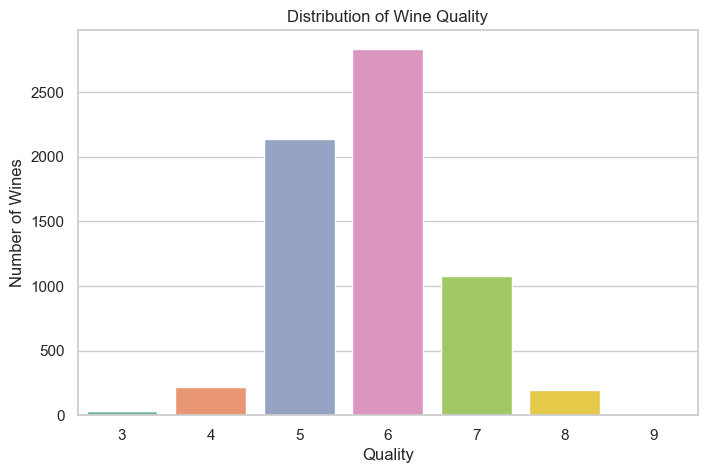

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=df, hue="quality", palette="Set2", legend=False)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of Wines")
plt.show()

In [64]:
quality_distribution = df["quality"].value_counts().sort_index()
quality_distribution

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [65]:
quality_distribution_normalized = df["quality"].value_counts(normalize=True).sort_index() * 100
quality_distribution_normalized.round(2)

quality
3     0.46
4     3.32
5    32.91
6    43.65
7    16.61
8     2.97
9     0.08
Name: proportion, dtype: float64

**Interpretation:**  
The target variable is not perfectly balanced. Most wines are concentrated around quality levels **5** and **6**, while extreme quality values are less frequent. This imbalance should be considered during modelling and interpretation.

### 6.2 Correlation heatmap
A correlation matrix helps identify linear relationships between features and with the target variable.

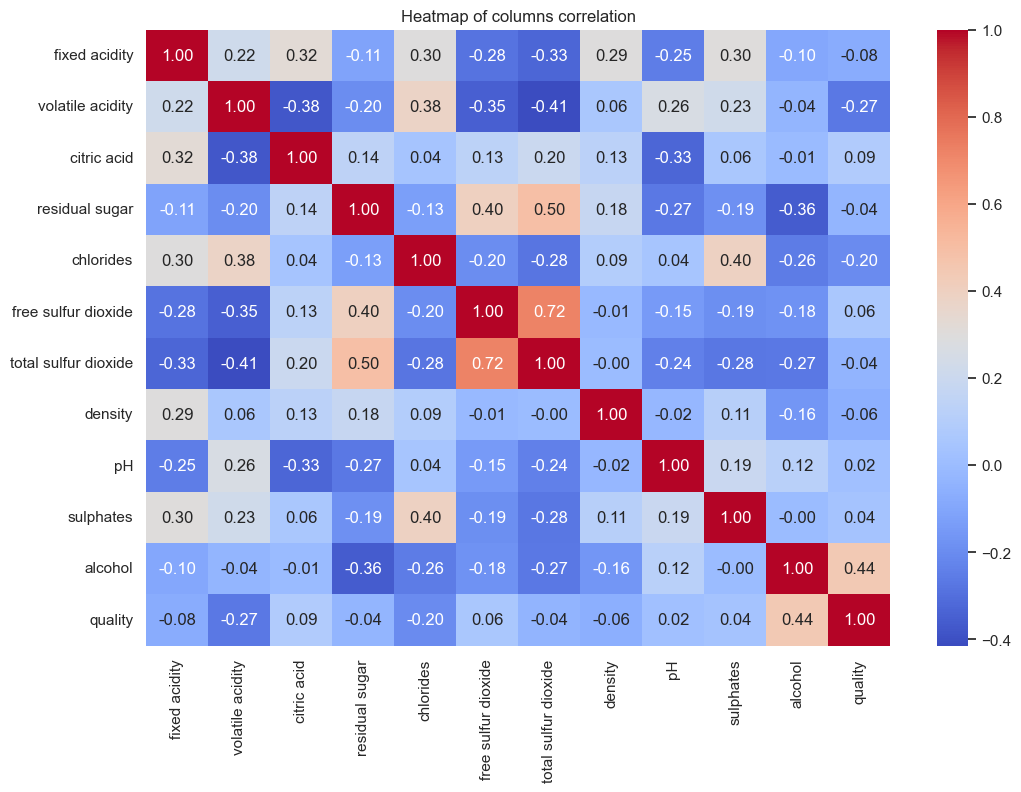

In [66]:
correlation = df.corr(numeric_only=True) # Will not use 'type' column because it is numeric

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of columns correlation')
plt.show()

**Interpretation:**  
This heatmap helps identify features that may be positively or negatively associated with wine quality.  
In this dataset, variables such as **alcohol** usually show a positive association with quality, while **volatile acidity** tends to show a negative one.

### 6.3 Scatter plots between important variables and quality
Scatter plots help visualise direct relationships between relevant features and the target variable.

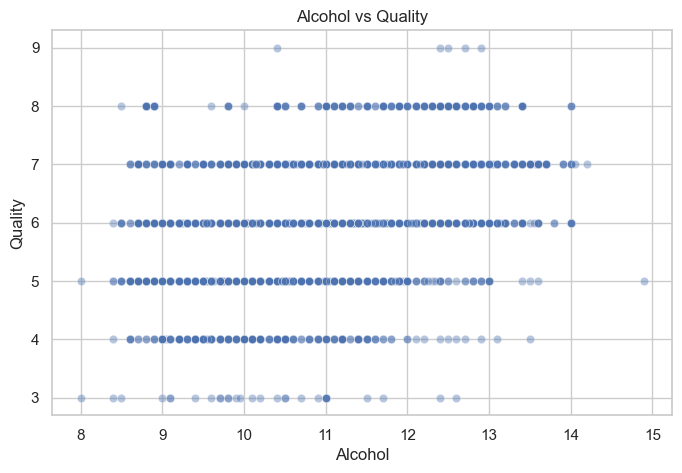

In [67]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='alcohol', y='quality', data=df, alpha=0.4)
plt.title('Alcohol vs Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

**Interpretation:**  
This plot suggests that wines with higher alcohol content tend to have higher quality scores, although the relationship is not perfectly linear.

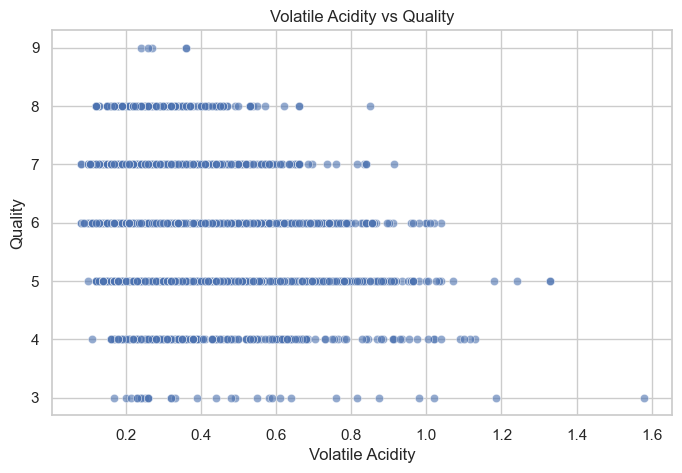

In [68]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='volatile acidity', y='quality', data=df, alpha=0.6)
plt.title('Volatile Acidity vs Quality')
plt.xlabel('Volatile Acidity')
plt.ylabel('Quality')
plt.show()

**Interpretation:**  
Higher volatile acidity is generally associated with lower quality scores, which is consistent with the correlations observed earlier.

### 6.4 Boxplots by quality
Boxplots are useful for visualising distributions and potential outliers for each feature across quality levels.

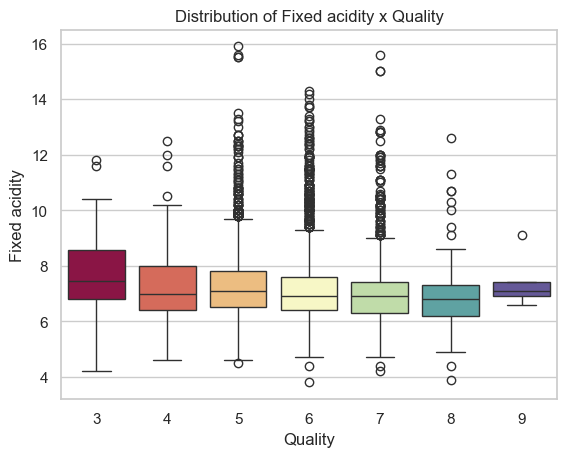

In [69]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='fixed acidity', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Fixed acidity x Quality')
plt.ylabel('Fixed acidity')
plt.xlabel('Quality')
plt.show()

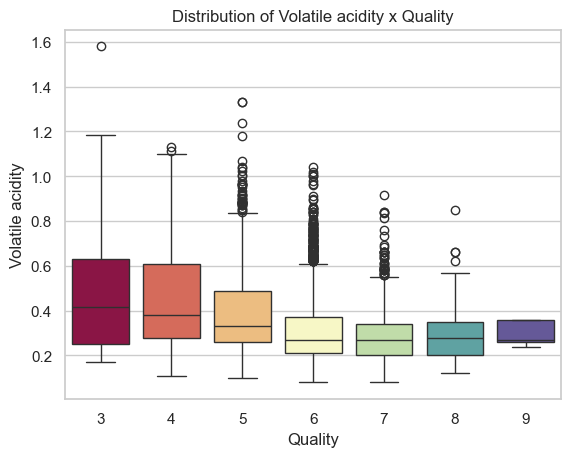

In [70]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='volatile acidity', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Volatile acidity x Quality')
plt.ylabel('Volatile acidity')
plt.xlabel('Quality')
plt.show()

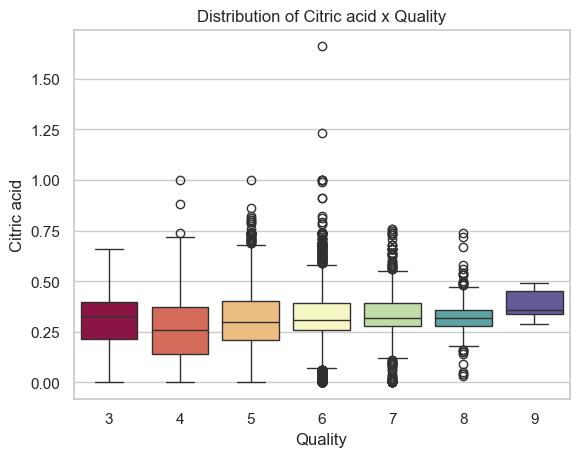

In [71]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='citric acid', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Citric acid x Quality')
plt.ylabel('Citric acid')
plt.xlabel('Quality')
plt.show()

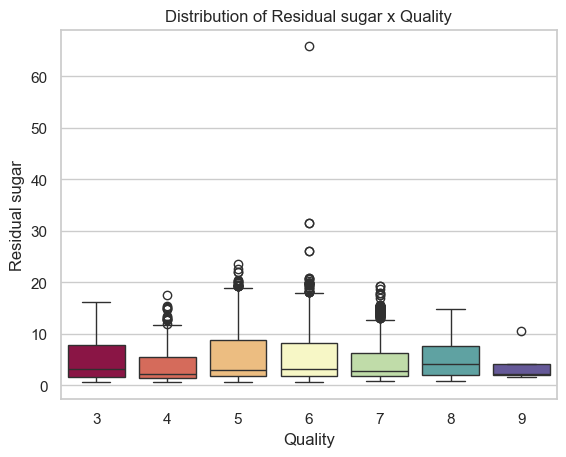

In [72]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='residual sugar', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Residual sugar x Quality')
plt.ylabel('Residual sugar')
plt.xlabel('Quality')
plt.show()

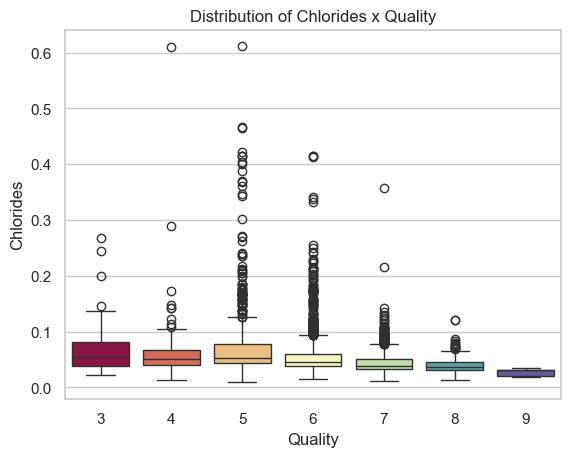

In [73]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='chlorides', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Chlorides x Quality')
plt.ylabel('Chlorides')
plt.xlabel('Quality')
plt.show()

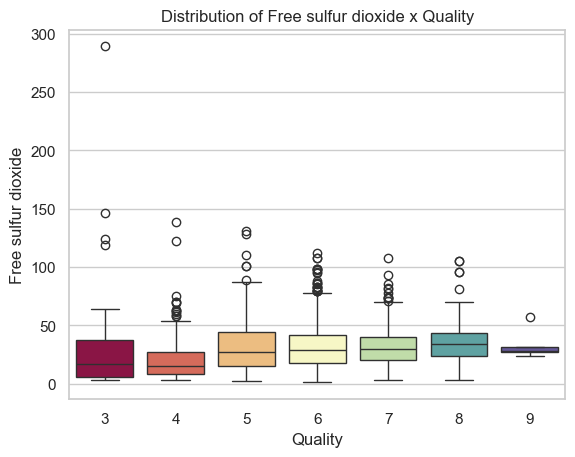

In [74]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='free sulfur dioxide', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Free sulfur dioxide x Quality')
plt.ylabel('Free sulfur dioxide')
plt.xlabel('Quality')
plt.show()

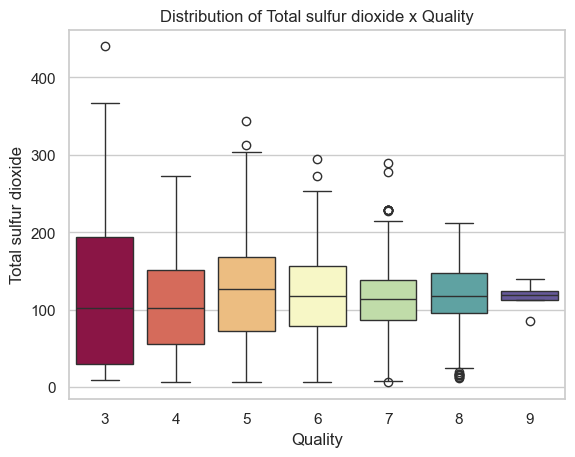

In [75]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='total sulfur dioxide', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Total sulfur dioxide x Quality')
plt.ylabel('Total sulfur dioxide')
plt.xlabel('Quality')
plt.show()

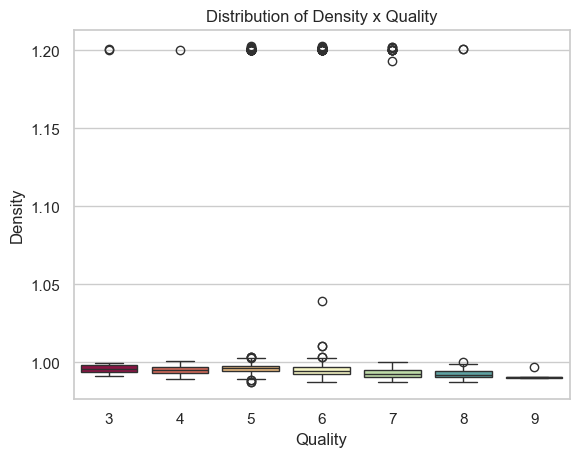

In [76]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='density', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Density x Quality')
plt.ylabel('Density')
plt.xlabel('Quality')
plt.show()

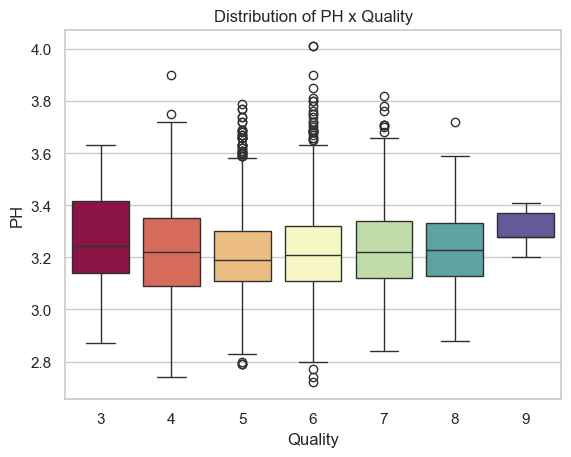

In [77]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='pH', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of PH x Quality')
plt.ylabel('PH')
plt.xlabel('Quality')
plt.show()

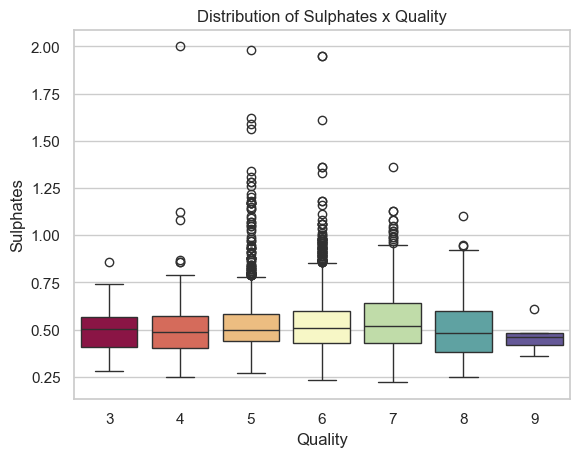

In [78]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='sulphates', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Sulphates x Quality')
plt.ylabel('Sulphates')
plt.xlabel('Quality')
plt.show()

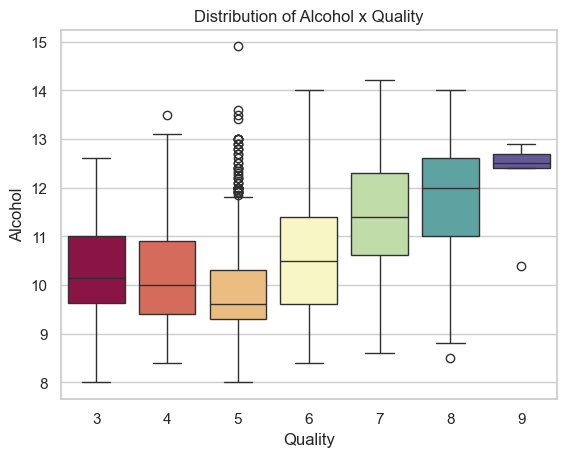

In [79]:
sns.set_theme(style="whitegrid")

sns.boxplot(x='quality', y='alcohol', data=df, hue='quality', palette='Spectral', legend=False)

plt.title('Distribution of Alcohol x Quality')
plt.ylabel('Alcohol')
plt.xlabel('Quality')
plt.show()

### 6.5 Histograms of the main variables
Histograms help us inspect the distribution of each numeric feature.

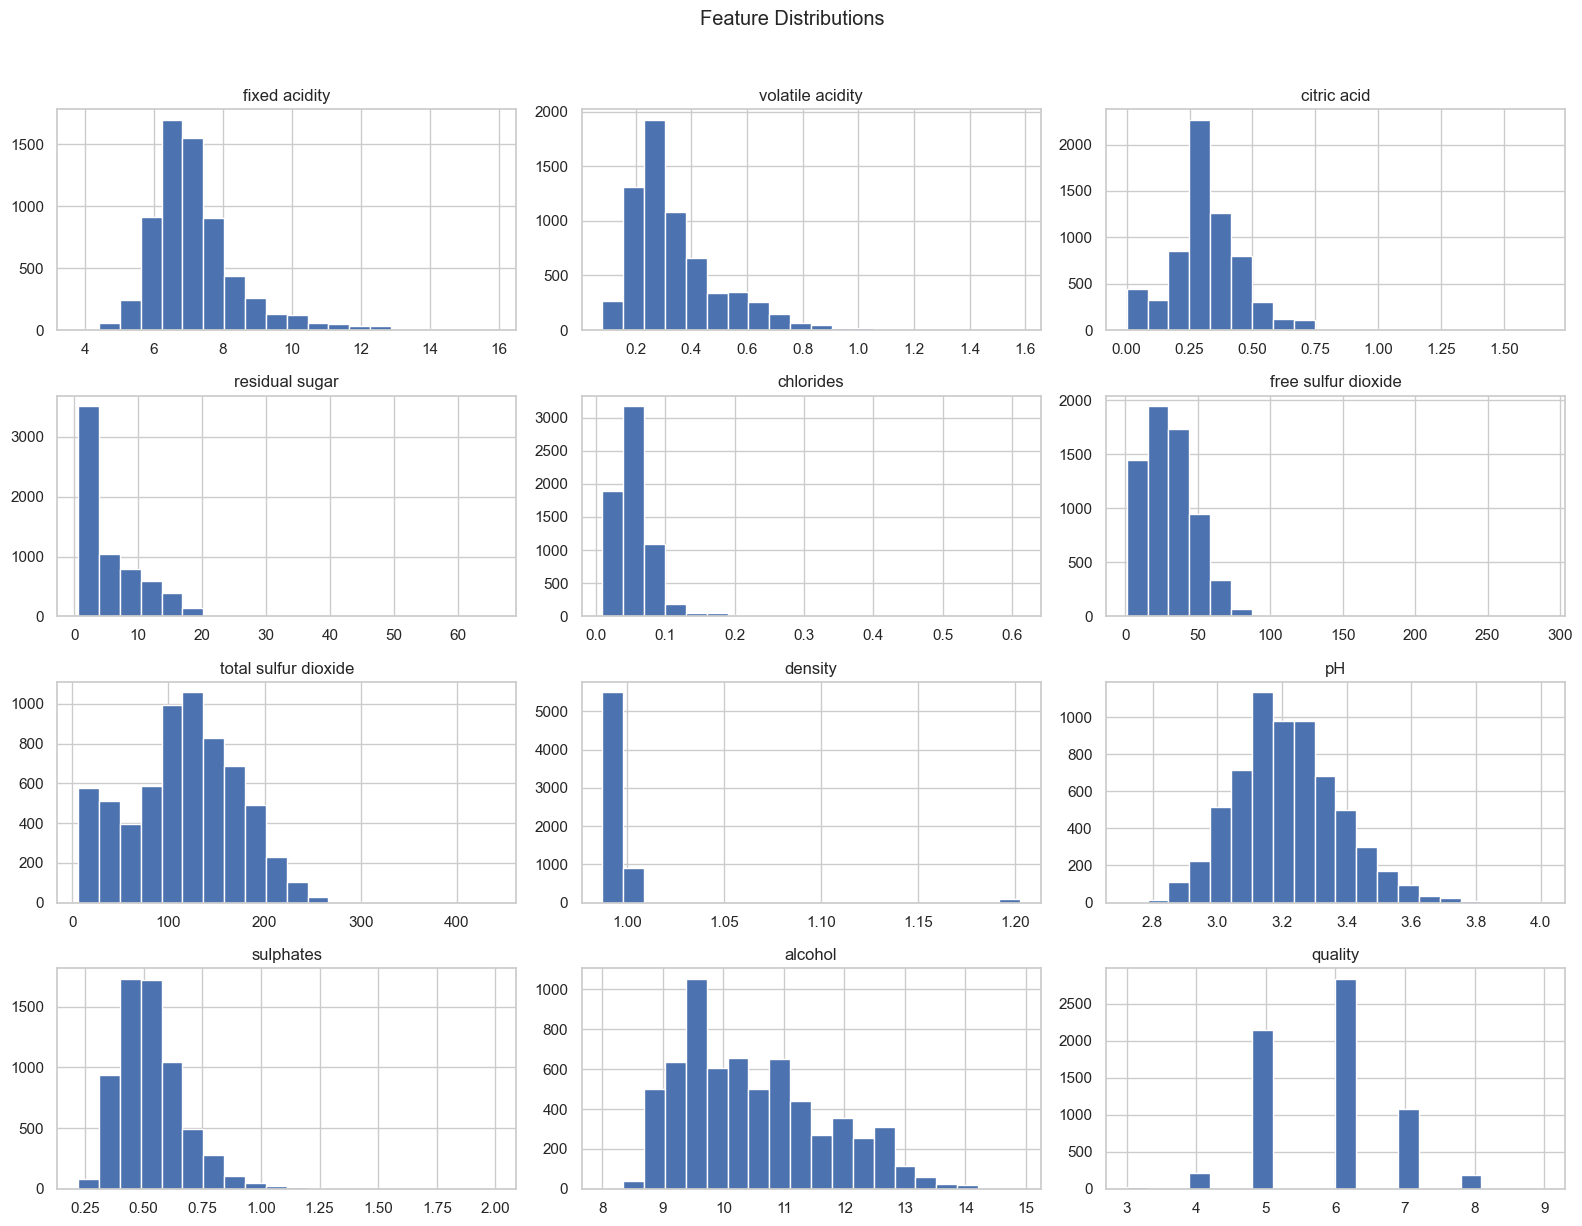

In [80]:
df.hist(figsize=(16, 12), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()